In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import joblib
import json

df = pd.read_csv('data/SMRT_features_v2.csv')

FEATURES = [c for c in df.columns if c not in ['pubchem', 'rt']]
TARGET = 'rt'

X = df[FEATURES]
y = df[TARGET]

print("Dataset shape:", X.shape)
print("Features:", len(FEATURES))
print("Any nulls:", X.isnull().sum().sum())

Dataset shape: (77901, 137)
Features: 137
Any nulls: 0


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train_sc.shape[0]} rows")
print(f"Test:  {X_test_sc.shape[0]} rows")

Train: 62320 rows
Test:  15581 rows


In [3]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=1
)

print("Training XGBoost... (~3-4 mins)")
model.fit(
    X_train_sc, y_train,
    eval_set=[(X_test_sc, y_test)],
    verbose=100
)
print("Done!")

Training XGBoost... (~3-4 mins)
[0]	validation_0-rmse:171.36691
[100]	validation_0-rmse:101.77696
[200]	validation_0-rmse:92.63343
[300]	validation_0-rmse:88.32557
[400]	validation_0-rmse:85.56009
[499]	validation_0-rmse:83.49387
Done!


R²:   0.7706
RMSE: 83.49 seconds


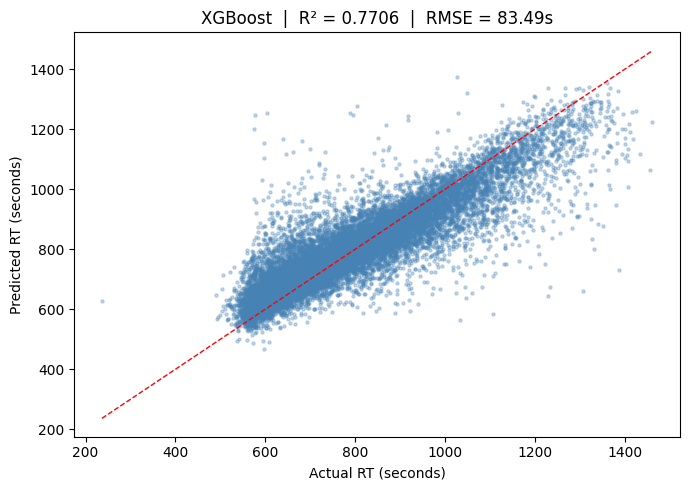

In [4]:
y_pred = model.predict(X_test_sc)

r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²:   {r2:.4f}")
print(f"RMSE: {rmse:.2f} seconds")

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.3, s=5, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=1)
plt.xlabel('Actual RT (seconds)')
plt.ylabel('Predicted RT (seconds)')
plt.title(f'XGBoost  |  R² = {r2:.4f}  |  RMSE = {rmse:.2f}s')
plt.tight_layout()
plt.savefig('data/xgb_performance.png', dpi=150)
plt.show()

In [5]:
joblib.dump(model,  'models/rt_predictor.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

model_info = {
    'model_name': 'XGBoost',
    'r2':         round(r2, 4),
    'rmse':       round(rmse, 2),
    'rt_filter':  200,
    'n_features': len(FEATURES),
    'features':   FEATURES
}

with open('models/model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)

print("Model saved to models/rt_predictor.pkl")
print("Scaler saved to models/scaler.pkl")
print("Info saved to models/model_info.json")
print(f"\nSummary: XGBoost | R²: {r2:.4f} | RMSE: {rmse:.2f}s")

Model saved to models/rt_predictor.pkl
Scaler saved to models/scaler.pkl
Info saved to models/model_info.json

Summary: XGBoost | R²: 0.7706 | RMSE: 83.49s
